In [1]:
'''데이터_2024_스마트폰과의존실태조사

- 작성일자: 2026.03.12
- 작성자 박영현
'''

'데이터_2024_스마트폰과의존실태조사\n\n- 작성일자: 2026.03.12\n- 작성자 박영현\n'

In [ ]:
# ============================================================
# 분석 설정
# AGE_FILTER = True  : 10~39세 필터링 적용 (팀 프로젝트 기준)
# AGE_FILTER = False : 전체 연령대 분석
# ============================================================
AGE_FILTER = True

In [2]:
import pandas as pd

In [3]:
extract_columns = ['Q11A1',
                     'Q11A2',
                     'Q11A3',
                     'Q11B1',
                     'Q11B2',
                     'Q11B3',
                     'Q12A1',
                     'Q12A2',
                     'Q12A3',
                     'Q33',
                     'Q71',
                     'Q72',
                     'Q71A',
                     'Q72A',
                     'Q73A']

def change_columns(df):
    df_cols_map = {col: col.replace('_', '') for col in df.columns}
    df = df.rename(columns=df_cols_map)
    return df

In [4]:
answer_df = pd.read_excel('./data/2024_smartphone_data.xlsx')
answer_df.head()

,SER,RID,CITYSIZE,HOUSE,SQ2,SQ3,SQ4_3,SQ5,SQ6,SQ8,...,Q25,Q26,Q26_ETC,DQ1,DQ2,DQ3,DQ4,DQ4_ETC,DQ5,wvar
0,1,1,2,1,1,1,67,1,1,1,...,NaN,NaN,NaN,4,2.0,NaN,5.0,NaN,3.0,1362.525773
1,2,2,2,1,1,1,35,1,1,1,...,NaN,NaN,NaN,5,2.0,NaN,7.0,NaN,4.0,1113.141026
2,3,2,2,1,2,2,32,1,1,1,...,NaN,NaN,NaN,5,2.0,NaN,4.0,NaN,3.0,957.578947
3,4,3,2,1,1,1,55,1,1,1,...,NaN,NaN,NaN,5,2.0,NaN,4.0,NaN,4.0,2901.454545
4,5,3,2,1,2,2,54,1,1,1,...,NaN,NaN,NaN,5,2.0,NaN,3.0,NaN,3.0,2764.863636


In [5]:
print(answer_df['SQ4_3'].describe())

if AGE_FILTER:
    answer_df = answer_df[(answer_df['SQ4_3'] >= 10) & (answer_df['SQ4_3'] < 40)]
    print('[AGE_FILTER=True] 10~39세 필터링 적용')
else:
    print('[AGE_FILTER=False] 전체 연령대 사용')

print(answer_df['SQ4_3'].describe())

count    24559.000000
mean        40.937864
std         17.707714
min          3.000000
25%         29.000000
50%         41.000000
75%         56.000000
max         69.000000
Name: SQ4_3, dtype: float64
count    10239.000000
mean        27.809259
std          8.450472
min         10.000000
25%         21.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: SQ4_3, dtype: float64


In [6]:
data_codebook = pd.read_excel('./data/2024_smartphone_data_codebook.xlsx', sheet_name='VAL')
data_codebook = data_codebook.ffill()
data_codebook.head()

,변수값,Unnamed: 1,Unnamed: 2
0,NaN,값,레이블
1,CITYSIZE,1,대도시
2,CITYSIZE,2,중소도시
3,CITYSIZE,3,읍/면지역
4,HOUSE,1,단독주택(다가구주택 포함)


In [7]:
data_codebook2 = pd.read_excel('./data/2024_smartphone_data_codebook.xlsx', sheet_name='VAR', header=1)
data_codebook2.head()

,변수,위치,레이블
0,SER,1,일련번호
1,RID,2,가구ID
2,CITYSIZE,3,도시규모별
3,HOUSE,4,주택형태
4,SQ2,5,가구주와의 관계


 ### 여기서 부터 수정 가능

In [8]:
# Q1_1A_1	[1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (1순위)
# Q1_1A_2	[1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (2순위)
# Q1_1A_3	[1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (2순위)
# Q1_1B_1	[1. 스마트폰 이용현황] [문1-1] 부작용으로 걱정되는 콘텐츠 (1순위)
# Q1_1B_2	[1. 스마트폰 이용현황] [문1-1] 부작용으로 걱정되는 콘텐츠 (2순위)
# Q1_1B_3	[1. 스마트폰 이용현황] [문1-1] 부작용으로 걱정되는 콘텐츠 (3순위)
# Q1_2A_1	[1. 스마트폰 이용현황] [문1-2] 이용량이 증가한 콘텐츠 (1순위)
# Q1_2A_2	[1. 스마트폰 이용현황] [문1-2] 이용량이 증가한 콘텐츠 (2순위)
# Q1_2A_3	[1. 스마트폰 이용현황] [문1-2] 이용량이 증가한 콘텐츠 (3순위)
# Q3_3	[1. 스마트폰 이용현황] [문3] SNS 이용시간 조절에 대한 어려움
# Q7_1	[2. 온라인 동영상 서비스 이용현황] [문7] 스마트폰을 통해 이용하고 있는 숏폼 플랫폼 (1순위)
# Q7_2	[2. 온라인 동영상 서비스 이용현황] [문7] 스마트폰을 통해 이용하고 있는 숏폼 플랫폼 (2순위)
# Q7_1A	[2. 온라인 동영상 서비스 이용현황] [문7-1] 숏폼이 온라인동영상 서비스 이용에서 차지하는 비중
# Q7_2A	[2. 온라인 동영상 서비스 이용현황] [문7-2] 본인의 의지대로 숏폼 시청을 조절하는 것에 느끼는 어려움
# Q7_3A	[2. 온라인 동영상 서비스 이용현황] [문7-3] AI의 추천 알고리즘에 의해 같은 유형의 숏폼 콘텐츠를 반복해서 보게 된다
# Q14_1	[4. 과의존 문제해결에 관한 인식] [문14] 심층경험 여부_시간 가는줄 모르고 숏폼, SNS 게시물을 보다가 예상보다 장시간 이용한 적이 있다

answer_df = change_columns(answer_df)
#print(answer_df.columns)
extract_answer_data = answer_df[extract_columns]
extract_answer_data.head()

##%%
#print(extract_answer_data.shape)
#print(extract_answer_data.dtypes)
#print(extract_answer_data.describe())
#
##%%
#print(extract_answer_data['Q72A'].value_counts())  # 숏폼 조절 어려움
#print(extract_answer_data['Q73A'].value_counts())  # AI 알고리즘 반복 시청
#print(extract_answer_data['Q33'].value_counts())   # SNS 이용시간 조절 어려움

,Q11A1,Q11A2,Q11A3,Q11B1,Q11B2,Q11B3,Q12A1,Q12A2,Q12A3,Q33,Q71,Q72,Q71A,Q72A,Q73A
1,3,5.0,8.0,12,9.0,19.0,8,9.0,12.0,2.0,4.0,3.0,2.0,2.0,3.0
2,8,10.0,21.0,8,9.0,6.0,8,9.0,5.0,2.0,4.0,3.0,1.0,2.0,3.0
5,6,5.0,7.0,5,4.0,19.0,6,9.0,13.0,2.0,1.0,2.0,2.0,2.0,3.0
6,25,6.0,7.0,3,13.0,NaN,8,25.0,9.0,2.0,1.0,4.0,2.0,2.0,2.0
8,2,5.0,10.0,7,3.0,13.0,9,13.0,NaN,2.0,1.0,3.0,2.0,2.0,2.0


In [9]:
# '변수값'라는 열에서 '_'를 제거하고 싶은 경우
data_codebook['변수값'] = data_codebook['변수값'].str.replace('_', '', regex=False)
data_codebook = data_codebook.rename(columns={'Unnamed: 1': '값', 'Unnamed: 2': '라벨'})
extract_data_codebook =  data_codebook[data_codebook['변수값'].isin(extract_columns)]
extract_data_codebook
#questions = data_codebook['변수값'].unique().tolist()
#questions

,변수값,값,라벨
250,Q11A1,98,없음
251,Q11A1,1,"SNS(페이스북, 인스타그램, 트위터, 카카오스토리, 밴드, 네이버카페, 다음카페 등)"
252,Q11A1,2,이메일
253,Q11A1,3,"메신저(카카오톡, 인스타 DM, 페이스북 메신저, 텔레그램 등)"
254,Q11A1,4,새로운 친구만남(어플리케이션)
...,...,...,...
827,Q72A,4,④ 매우 그렇다
828,Q73A,1,① 전혀그렇지 않다
829,Q73A,2,② 그렇지 않다
830,Q73A,3,③ 그렇다


In [10]:
data_codebook2['변수'] = data_codebook2['변수'].str.replace('_', '', regex=False)
data_codebook2 =  data_codebook2[data_codebook2['변수'].isin(extract_columns)]
data_codebook2

,변수,위치,레이블
40,Q11A1,41,[1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (1순위)
41,Q11A2,42,[1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (2순위)
42,Q11A3,43,[1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (2순위)
43,Q11B1,44,[1. 스마트폰 이용현황] [문1-1] 부작용으로 걱정되는 콘텐츠 (1순위)
44,Q11B2,45,[1. 스마트폰 이용현황] [문1-1] 부작용으로 걱정되는 콘텐츠 (2순위)
45,Q11B3,46,[1. 스마트폰 이용현황] [문1-1] 부작용으로 걱정되는 콘텐츠 (3순위)
46,Q12A1,47,[1. 스마트폰 이용현황] [문1-2] 이용량이 증가한 콘텐츠 (1순위)
47,Q12A2,48,[1. 스마트폰 이용현황] [문1-2] 이용량이 증가한 콘텐츠 (2순위)
48,Q12A3,49,[1. 스마트폰 이용현황] [문1-2] 이용량이 증가한 콘텐츠 (3순위)
57,Q33,58,[1. 스마트폰 이용현황] [문3] SNS 이용시간 조절에 대한 어려움


In [11]:
extract_data_codebook['값'] = extract_data_codebook['값'].astype(str)

C:\Users\KDS24\AppData\Local\Temp\ipykernel_13780\123653343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extract_data_codebook['값'] = extract_data_codebook['값'].astype(str)


In [12]:
# 변수별 매핑 딕셔너리 생성
mapping = {}
for var in extract_columns:
    temp = extract_data_codebook[extract_data_codebook['변수값'] == var].set_index('값')['라벨'].to_dict()
    mapping[var] = temp
mapping['Q33']

{'1': '① 전혀 그렇지 않다', '2': '② 그렇지 않다', '3': '③ 그렇다', '4': '④ 매우 그렇다'}

In [13]:
# 데이터에 라벨 적용
for var in extract_columns:
    if var in answer_df.columns:
        answer_df[var] = answer_df[var].astype('Int64').fillna(answer_df[var])
        answer_df[var] = answer_df[var].astype('str')
        answer_df[f'{var}_라벨'] = answer_df[var].map(mapping[var])

#print(answer_df.columns)

In [14]:
# A컬럼을 Key로, B컬럼을 Value로 변환
result_dict = dict(zip(data_codebook2['변수'], data_codebook2['레이블']))
result_dict

for column in extract_columns:
    print(f"\n{'='*50}")
    print(f"컬럼: {column}")
    print(f"질문: {result_dict.get(column, '질문 없음')}")
    
    # 0명 포함한 전체 카운트 만들기
    counts = []
    for val, label in sorted(mapping[column].items()):
        count = (answer_df[column] == val).sum()
        counts.append({'index': val, 'answer': label, 'count': count})
    
    count_df = pd.DataFrame(counts)
    print(count_df)
    
    # CSV 저장 (0명 포함)
    count_df.to_csv(f'./data/output/{result_dict[column].replace('/', '_').replace('\\', '_')}.csv', index=False)


컬럼: Q11A1
질문: [1. 스마트폰 이용현황] [문1-1] 생활에 도움이 되는 콘텐츠 (1순위)
   index                                            answer  count
0      1  SNS(페이스북, 인스타그램, 트위터, 카카오스토리, 밴드, 네이버카페, 다음카페 등)   1090
1     10                                    금융거래(인터넷 뱅킹 등)    553
2     11                           투자 및 자산관리(주식 거래, 재테크 등)    103
3     12                                                게임    158
4     13                            영화/TV/동영상(유튜브, 넷플릭스 등)    572
5     14                                                음악    210
6     15                                          라디오/팟캐스트     23
7     16                                       웹툰/웹소설/독서 등     49
8     17                                    사진(촬영 편집) 및 그림     72
9     18                                                여행     53
10    19                                            성인용콘텐츠      2
11     2                                               이메일    155
12    20                           사행성게임(스포츠 베팅, 온라인 도박 등)      2
13    21          

### 숏폼 비중이 높을수록 조절이 어려워지는가?: 강한 상관관계

In [15]:

#extract_answer_data.head()

import matplotlib.pyplot as plt
import koreanize_matplotlib

def mean_result_correlation(target):
    # 숏폼 비중별 조절 어려움 평균
    mean_result = extract_answer_data.groupby(target)['Q72A'].mean()
    print(mean_result)
    print()
    
    correlation = extract_answer_data[target].corr(extract_answer_data['Q72A'])
    print(f"상관계수: {correlation:.2f}") # 0.51: 뚜렷한 양의 상관관계
    
    return mean_result

Q71A
1.0    1.656054
2.0    2.214579
3.0    2.731707
4.0    3.285714
Name: Q72A, dtype: float64

상관계수: 0.54


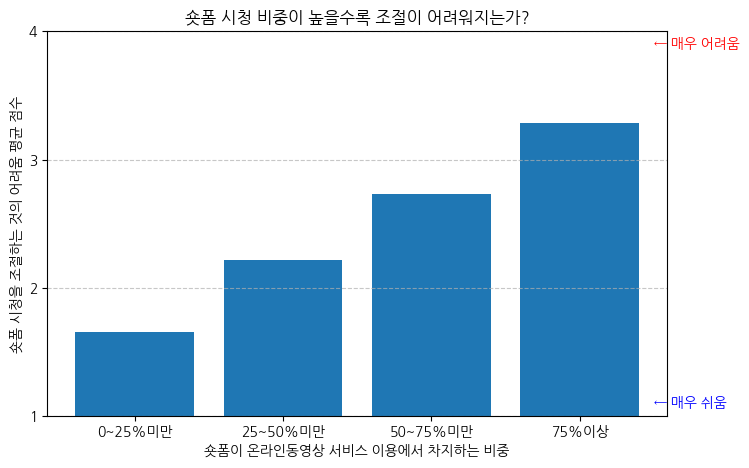

In [16]:
mean_result = mean_result_correlation('Q71A')

import matplotlib.pyplot as plt
import matplotlib

# 레이블 딕셔너리
x_labels = {
    1: '0~25%미만',
    2: '25~50%미만',
    3: '50~75%미만',
    4: '75%이상'
}

plt.figure(figsize=(8, 5))
plt.bar(
    [x_labels[k] for k in mean_result.index],
    mean_result.values
)
plt.xlabel('숏폼이 온라인동영상 서비스 이용에서 차지하는 비중')
plt.ylabel('숏폼 시청을 조절하는 것의 어려움 평균 점수')
plt.title('숏폼 시청 비중이 높을수록 조절이 어려워지는가?')
plt.ylim(1, 4)
plt.yticks([1, 2, 3, 4])
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
right_end = len(mean_result) - 0.5
plt.text(right_end, 1.1, '← 매우 쉬움', va='center', color='blue', fontsize=10)
plt.text(right_end, 3.9, '← 매우 어려움', va='center', color='red', fontsize=10)
plt.show()

### 알고리즘에 의해 같은 유형 숏폼 반복 시청 할수록 숏폼 콘텐츠를 반복해서 보게 되는가?: 강한 상관관계

Q73A
1.0    1.330971
2.0    2.119196
3.0    2.607303
4.0    3.103044
Name: Q72A, dtype: float64

상관계수: 0.64


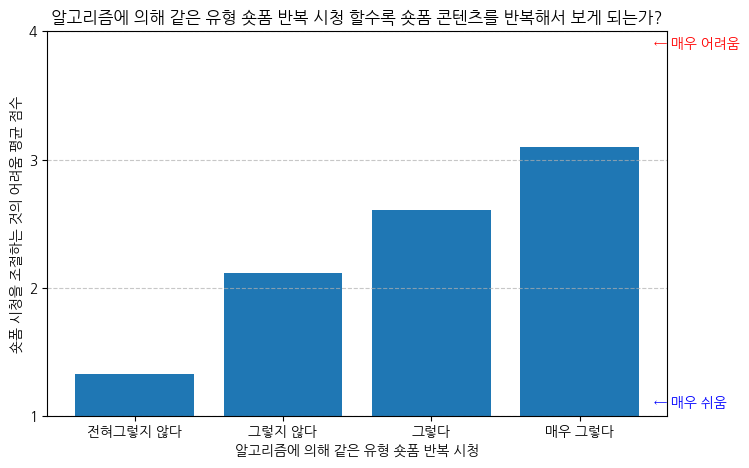

In [17]:
mean_result = mean_result_correlation('Q73A')

x_labels = {
    1: '전혀그렇지 않다',
    2: '그렇지 않다',
    3: '그렇다',
    4: '매우 그렇다'
}

plt.figure(figsize=(8, 5))
plt.bar(
    [x_labels[k] for k in mean_result.index],
    mean_result.values
)
plt.xlabel('알고리즘에 의해 같은 유형 숏폼 반복 시청')
plt.ylabel('숏폼 시청을 조절하는 것의 어려움 평균 점수')
plt.title('알고리즘에 의해 같은 유형 숏폼 반복 시청 할수록 숏폼 콘텐츠를 반복해서 보게 되는가?')
plt.ylim(1, 4)
plt.yticks([1, 2, 3, 4])
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
right_end = len(mean_result) - 0.5
plt.text(right_end, 1.1, '← 매우 쉬움', va='center', color='blue', fontsize=10)
plt.text(right_end, 3.9, '← 매우 어려움', va='center', color='red', fontsize=10)
plt.show()

### SNS 이용시간 조절 어려울 수록 SNS 이용시간 조절 어려운가?: 중간 상관관계

Q33
1.0    1.852264
2.0    2.098209
3.0    2.522669
4.0    2.913793
Name: Q72A, dtype: float64

상관계수: 0.38


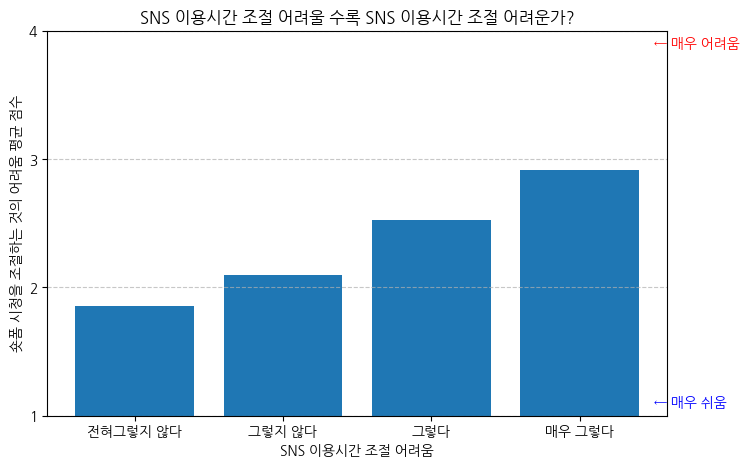

In [18]:
mean_result = mean_result_correlation('Q33')

x_labels = {
    1: '전혀그렇지 않다',
    2: '그렇지 않다',
    3: '그렇다',
    4: '매우 그렇다'
}

plt.figure(figsize=(8, 5))
plt.bar(
    [x_labels[k] for k in mean_result.index],
    mean_result.values
)
plt.xlabel('SNS 이용시간 조절 어려움')
plt.ylabel('숏폼 시청을 조절하는 것의 어려움 평균 점수')
plt.title('SNS 이용시간 조절 어려울 수록 SNS 이용시간 조절 어려운가?')
plt.ylim(1, 4)
plt.yticks([1, 2, 3, 4])
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
right_end = len(mean_result) - 0.5
plt.text(right_end, 1.1, '← 매우 쉬움', va='center', color='blue', fontsize=10)
plt.text(right_end, 3.9, '← 매우 어려움', va='center', color='red', fontsize=10)
plt.show()

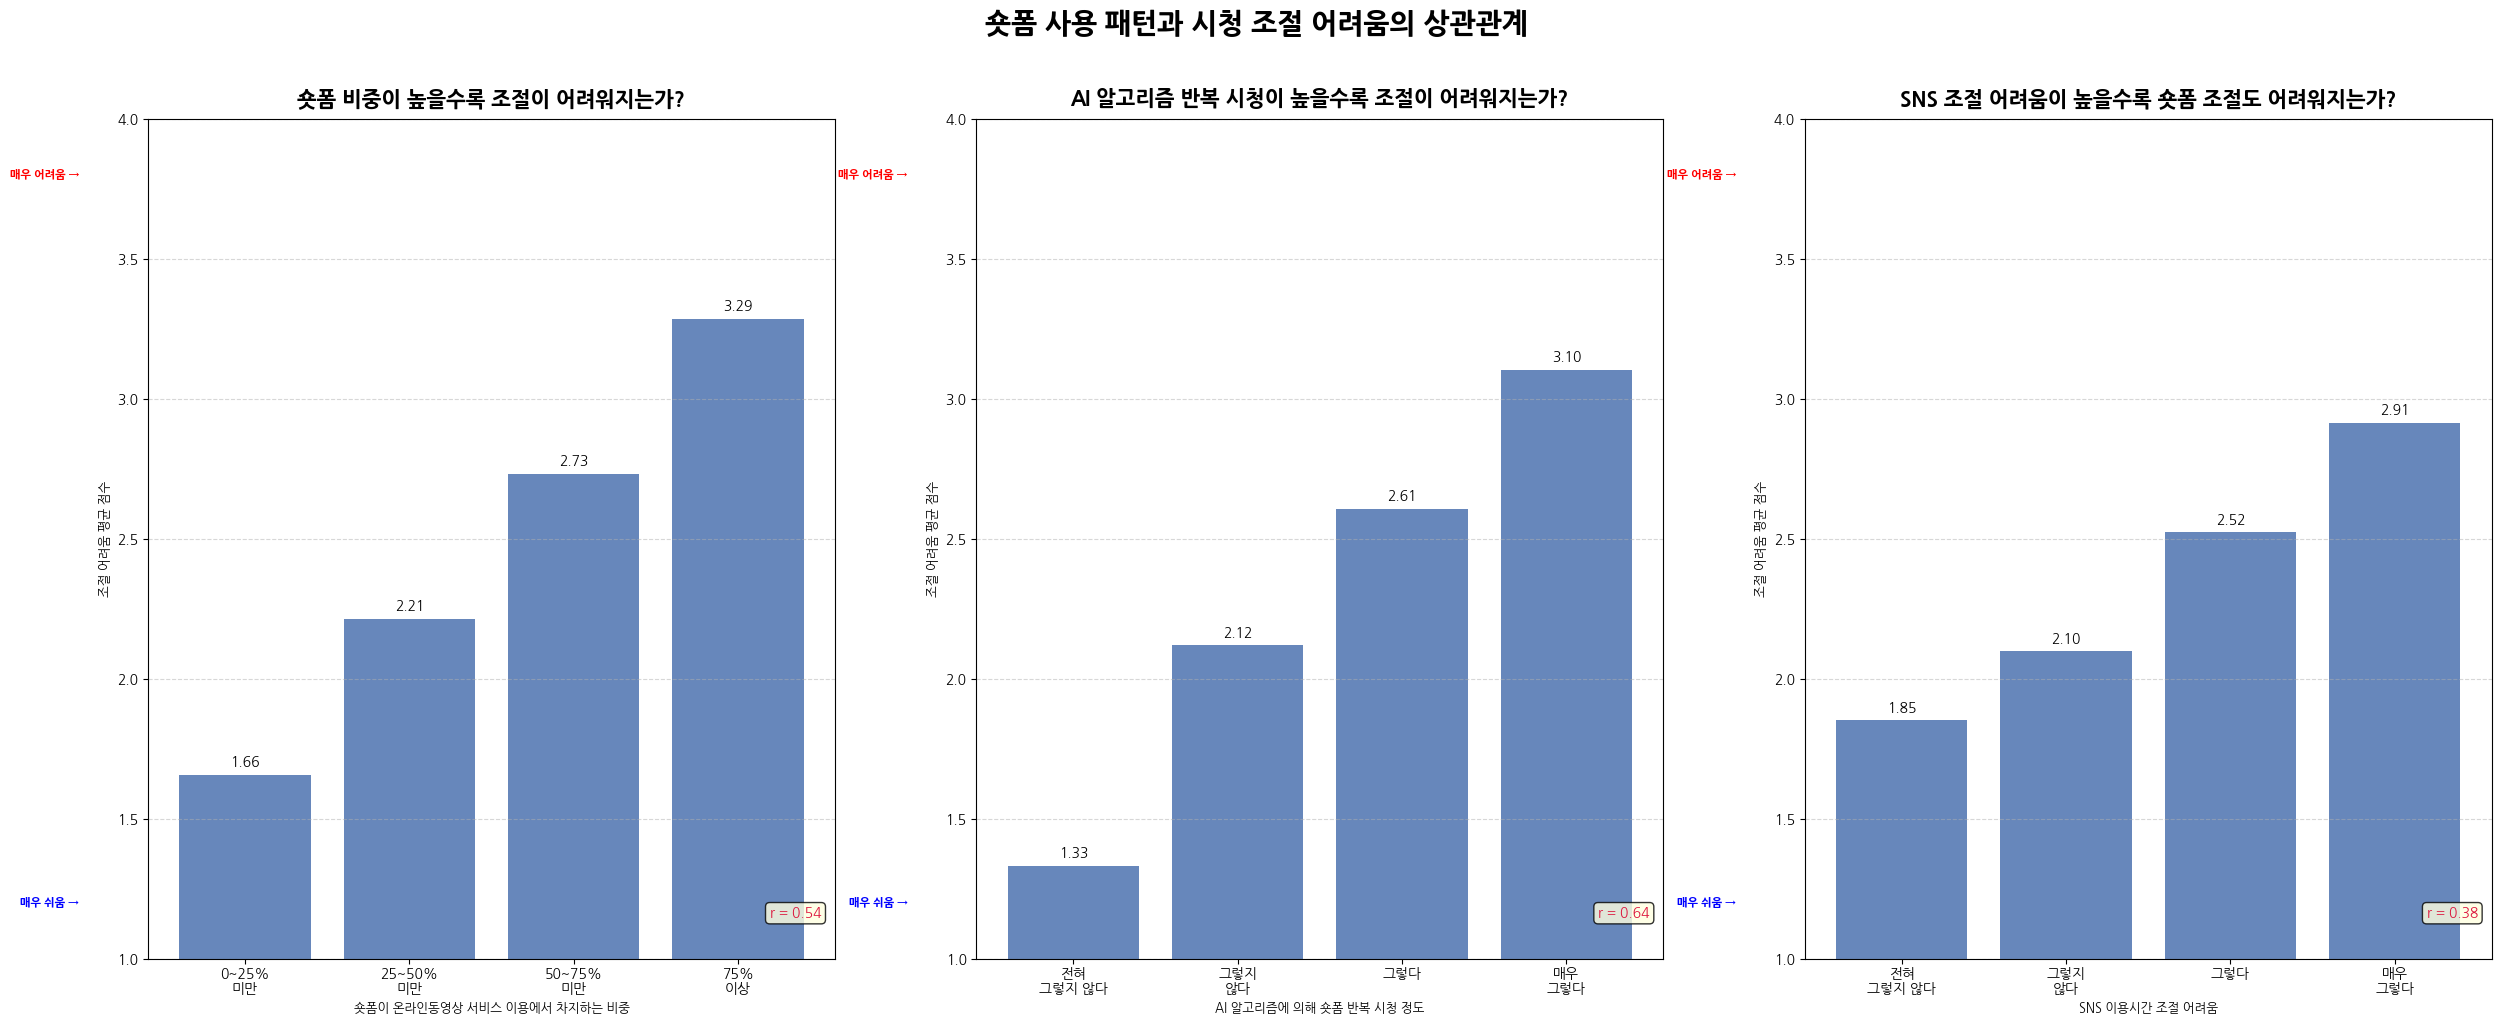

In [19]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

fig, axes = plt.subplots(1, 3, figsize=(25, 10))

charts = [
    {
        'target': 'Q71A',
        'title': '숏폼 비중이 높을수록 조절이 어려워지는가?',
        'xlabel': '숏폼이 온라인동영상 서비스 이용에서 차지하는 비중',
        'labels': {1: '0~25%\n미만', 2: '25~50%\n미만', 3: '50~75%\n미만', 4: '75%\n이상'},
        'corr': 0.54
    },
    {
        'target': 'Q73A',
        'title': 'AI 알고리즘 반복 시청이 높을수록 조절이 어려워지는가?',
        'xlabel': 'AI 알고리즘에 의해 숏폼 반복 시청 정도',
        'labels': {1: '전혀\n그렇지 않다', 2: '그렇지\n않다', 3: '그렇다', 4: '매우\n그렇다'},
        'corr': 0.64
    }, {
        'target': 'Q33',
        'title': 'SNS 조절 어려움이 높을수록 숏폼 조절도 어려워지는가?',
        'xlabel': 'SNS 이용시간 조절 어려움',
        'labels': {1: '전혀\n그렇지 않다', 2: '그렇지\n않다', 3: '그렇다', 4: '매우\n그렇다'},
        'corr': 0.38
    }
]

for ax, chart in zip(axes.flatten(), charts):
    mean_result = extract_answer_data.groupby(chart['target'])['Q72A'].mean()
    x_labels = [chart['labels'][k] for k in mean_result.index]

    bars = ax.bar(x_labels, mean_result.values, color='#4C72B0', alpha=0.85)

    # 막대 위 수치
    for bar, val in zip(bars, mean_result.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

    ax.set_title(chart['title'], fontsize=15, fontweight='bold', pad=10)
    ax.set_xlabel(chart['xlabel'], fontsize=9)
    ax.set_ylabel('조절 어려움 평균 점수', fontsize=9)
    ax.set_ylim(1, 4)
    ax.yticks = [1, 2, 3, 4]
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 상관계수 표시
    ax.text(0.98, 0.05, f'r = {chart["corr"]}',
            transform=ax.transAxes, ha='right',
            fontsize=10, color='crimson',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    # y축 레이블
    ax.text(-0.1, 1.2, '매우 쉬움 →', transform=ax.get_yaxis_transform(),
            ha='right', va='center', color='blue', fontsize=8, fontweight='bold')
    ax.text(-0.1, 3.8, '매우 어려움 →', transform=ax.get_yaxis_transform(),
            ha='right', va='center', color='red', fontsize=8, fontweight='bold')

plt.suptitle('숏폼 사용 패턴과 시청 조절 어려움의 상관관계', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./data/output/상관관계_시각화.png', dpi=150, bbox_inches='tight')
plt.show()

### 모델


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib

def print_model(extract_answer_data, features):
    target = 'Q72A' # [2. 온라인 동영상 서비스 이용현황] [문7-2] 본인의 의지대로 숏폼 시청을 조절하는 것에 느끼는 어려움

    # 필요한 컬럼만 추출
    extract_answer_data = extract_answer_data[features + [target]]
    extract_answer_data.isnull().sum()
    
    model_df = extract_answer_data.dropna()
    print(model_df)

    # Target 이진 변환
    # 1~2점 → 0 (안전)
    # 3~4점 → 1 (위험)
    model_df['target'] = (model_df[target] >= 3).astype(int)

    # 비율 확인
    print(model_df['target'].value_counts(normalize=True))
    print(f"전체 행 수: {len(model_df)}")
    
    return model_df


In [21]:
# Feature, Target 선택
features = ['Q71A', 'Q73A', 'Q33']
model_df = print_model(extract_answer_data, features)

       Q71A  Q73A  Q33  Q72A
1       2.0   3.0  2.0   2.0
2       1.0   3.0  2.0   2.0
5       2.0   3.0  2.0   2.0
6       2.0   2.0  2.0   2.0
8       2.0   2.0  2.0   2.0
...     ...   ...  ...   ...
24541   1.0   1.0  1.0   1.0
24552   1.0   1.0  1.0   1.0
24556   1.0   2.0  1.0   2.0
24557   1.0   2.0  1.0   2.0
24558   1.0   2.0  1.0   2.0

[8715 rows x 4 columns]
target
0    0.619966
1    0.380034
Name: proportion, dtype: float64
전체 행 수: 8715


C:\Users\KDS24\AppData\Local\Temp\ipykernel_13780\2063649154.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['target'] = (model_df[target] >= 3).astype(int)


In [22]:
X = model_df[['Q71A', 'Q73A', 'Q33']]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 베이스라인
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.86      0.84      1047
           1       0.77      0.70      0.74       696

    accuracy                           0.80      1743
   macro avg       0.79      0.78      0.79      1743
weighted avg       0.80      0.80      0.80      1743

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1047
           1       0.77      0.71      0.74       696

    accuracy                           0.80      1743
   macro avg       0.79      0.78      0.79      1743
weighted avg       0.80      0.80      0.80      1743



In [23]:
model_df['target'].value_counts()

target
0    5403
1    3312
Name: count, dtype: int64

[0.34889638 0.46773362 0.18337   ]


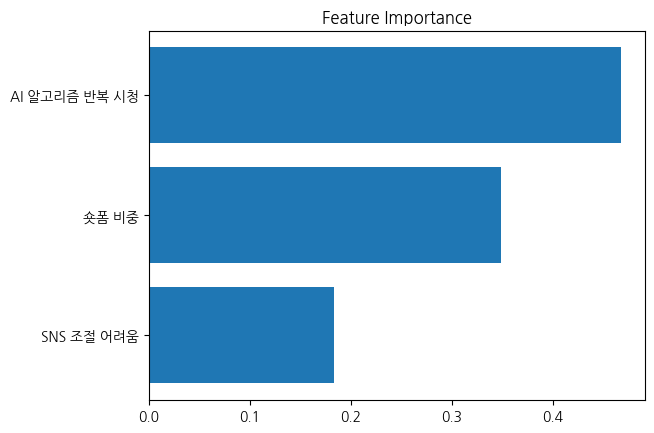

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
    
features = ['숏폼 비중', 'AI 알고리즘 반복 시청', 'SNS 조절 어려움']
importances = rf.feature_importances_
print(importances)

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.barh(fi_df['Feature'], fi_df['Importance'])
plt.title('Feature Importance')
plt.show()

[0.34889638 0.46773362 0.18337   ]


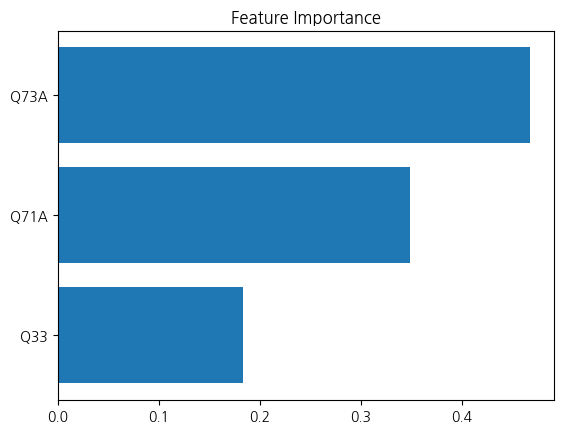

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
    
features = ['Q71A', 'Q73A', 'Q33']
importances = rf.feature_importances_
print(importances)

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.barh(fi_df['Feature'], fi_df['Importance'])
plt.title('Feature Importance')
plt.show()

In [26]:
import numpy as np

# 테스트셋 예측 확률
proba_1 = rf.predict_proba(X_test)[:, 1]

# 분포 확인
print(f"33% 기준점: {np.percentile(proba_1, 33):.2f}")
print(f"66% 기준점: {np.percentile(proba_1, 66):.2f}")
print(f"평균: {np.mean(proba_1):.2f}")

33% 기준점: 0.12
66% 기준점: 0.60
평균: 0.38


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[895 152]
 [199 497]]


In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1047
           1       0.78      0.70      0.74       696

    accuracy                           0.80      1743
   macro avg       0.79      0.78      0.79      1743
weighted avg       0.80      0.80      0.80      1743



In [29]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score

# 탐색할 파라미터 공간
space = {
    'n_estimators': hp.choice('n_estimators', [100, 200, 300]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 10]),
    'min_samples_split': hp.choice('min_samples_split', [2, 5, 10]),
    'min_samples_leaf': hp.choice('min_samples_leaf', [1, 2, 4])
}

# 목적 함수
def objective(params):
    rf_tuned = RandomForestClassifier(
        **params,
        random_state=42
    )
    score = cross_val_score(
        rf_tuned, X_train, y_train,
        cv=5, scoring='recall'  # 위험군 Recall 최대화
    ).mean()
    return {'loss': -score, 'status': STATUS_OK}

# 최적화 실행
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials
)

print("최적 파라미터:", best)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

c:\Users\KDS24\anaconda3\envs\bigdata\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


100%|██████████| 50/50 [01:15<00:00,  1.50s/trial, best loss: -0.7113992964838791]
최적 파라미터: {'max_depth': np.int64(1), 'min_samples_leaf': np.int64(2), 'min_samples_split': np.int64(1), 'n_estimators': np.int64(2)}


In [30]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

print("=== RF Tuned ===")
print(classification_report(y_test, y_pred_tuned))

=== RF Tuned ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1047
           1       0.76      0.72      0.74       696

    accuracy                           0.80      1743
   macro avg       0.79      0.78      0.79      1743
weighted avg       0.80      0.80      0.80      1743



In [31]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('lr', LogisticRegression()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

print("=== Stacking ===")
print(classification_report(y_test, y_pred_stack))

=== Stacking ===
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1047
           1       0.78      0.70      0.74       696

    accuracy                           0.80      1743
   macro avg       0.80      0.78      0.79      1743
weighted avg       0.80      0.80      0.80      1743



In [32]:
# Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)

# Feature Importance
print(rf_tuned.feature_importances_)

[[892 155]
 [198 498]]
[0.34390301 0.47221437 0.18388262]


In [33]:
import joblib
joblib.dump(rf_tuned, './model/addiction_model.pkl')

['./model/addiction_model.pkl']

## 모델별 성능 비교 히트맵

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

data = {
    'Logistic Regression': [0.83, 0.72, 0.67, 0.78],
    'Random Forest': [0.84, 0.74, 0.71, 0.77],
    'XGBoost': [0.84, 0.74, 0.70, 0.78],
    'RF Tuned (HyperOpt)': [0.83, 0.74, 0.72, 0.76],
    'Stacking': [0.84, 0.74, 0.70, 0.78]
}
metrics = ['안전(0) F1', '위험(1) F1', '위험(1) 재현율(Recall)', '위험(1) 정밀도(Precision)']
df_hm = pd.DataFrame(data, index=metrics)

plt.figure(figsize=(10, 6))
sns.heatmap(df_hm, annot=True, cmap='Reds', fmt='.2f', linewidths=.5, cbar_kws={'label': 'Score'})
plt.title('모델별 성능 평가 지표 비교 (위험군 재현율 중심)', fontsize=15, pad=20)
plt.xticks(rotation=45)
plt.ylabel('평가 지표')
plt.xlabel('예측 모델')
plt.tight_layout()
plt.show()